# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game player data, splitting into train/test sets, creating datasets and
dataloaders from them, hyperparameter tuning a `FootballLSTM` instance, training it,
and evaluating it.

In [1]:
import sys
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt
import numpy as np

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset, DifferencedFootballDataset, merge_stats_df_with_transfermarkt
from football_lstm import FootballLSTM, DifferencingFootballLSTM
from utils import hyperparam_tuning, get_actuals_vs_predictions_df

In [2]:
# have GPU available to speed up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cpu


In [3]:
# Choose what stats to forecast, what position(s) to use, whether to use differencing,
# how many past games to predict future games
stats = ["xG", "xA", "key_passes", "xGChain", "xGBuildup"]
per_90_stats = list(map(lambda s: f"{s}_per_90", stats))
positions = ['M']
differencing = True
blocks_per_input = 5

In [4]:
# Read in saved df - use pull_understat_data as needed if desired data hasn't been pulled
stats_df = pd.read_csv(f"../data/{'_'.join(positions)}_stats.csv")

# Convert date to appropriate type
stats_df['date'] = pd.to_datetime(stats_df['date'])

stats_df = stats_df.set_index(['player_id', 'player_name', 'date', 'league'])

stats_df = stats_df[per_90_stats] # Only include appropriate stats

stats_df.head()

xG_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.040743   
                            2015-03-22 14:30:00 Bundesliga   0.021087   
                            2015-09-12 17:30:00 Bundesliga   0.079120   
                            2015-11-29 20:30:00 Bundesliga   0.072270   
                            2016-03-19 18:30:00 Bundesliga   0.047304   

                                                            xA_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.035318   
                            2015-03-22 14:30:00 Bundesliga   0.005730   
                            2015-09-12 17:30:00 Bundesliga   0.025244   
                            2015-11-29 20:30:00 Bundesliga   0.010650   
                            2016-03-19 18:30:00 Bundesliga   0.031790   

                                                            key_passes_per_90  \
player_id player_name       date                league                          
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga           0.690537   
                            2015-03-22 14:30:00 Bundesliga           0.284810   
                            2015-09-12 17:30:00 Bundesliga           0.855784   
                            2015-11-29 20:30:00 Bundesliga           0.613915   
                            2016-03-19 18:30:00 Bundesliga           0.793451   

                                                            xGChain_per_90  \
player_id player_name       date                league                       
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga        0.250601   
                            2015-03-22 14:30:00 Bundesliga        0.287882   
                            2015-09-12 17:30:00 Bundesliga        0.487742   
                            2015-11-29 20:30:00 Bundesliga        0.398019   
                            2016-03-19 18:30:00 Bundesliga        0.377149   

                                                            xGBuildup_per_90  
player_id player_name       date                league                        
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga          0.211696  
                            2015-03-22 14:30:00 Bundesliga          0.270286  
                            2015-09-12 17:30:00 Bundesliga          0.397243  
                            2015-11-29 20:30:00 Bundesliga          0.378410  
                            2016-03-19 18:30:00 Bundesliga          0.342835

In [5]:
# Train/test split by player
all_players = stats_df.index.get_level_values('player_id').unique()

# 80/20 split
np.random.seed(42)
train_players = np.random.choice(all_players, size=int(0.8*len(all_players)), replace=False)

train_df = stats_df[stats_df.index.get_level_values('player_id').isin(train_players)].copy()
test_df = stats_df[~stats_df.index.get_level_values('player_id').isin(train_players)].copy()

In [6]:
train_df.head()

xG_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.040743   
                            2015-03-22 14:30:00 Bundesliga   0.021087   
                            2015-09-12 17:30:00 Bundesliga   0.079120   
                            2015-11-29 20:30:00 Bundesliga   0.072270   
                            2016-03-19 18:30:00 Bundesliga   0.047304   

                                                            xA_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.035318   
                            2015-03-22 14:30:00 Bundesliga   0.005730   
                            2015-09-12 17:30:00 Bundesliga   0.025244   
                            2015-11-29 20:30:00 Bundesliga   0.010650   
                            2016-03-19 18:30:00 Bundesliga   0.031790   

                                                            key_passes_per_90  \
player_id player_name       date                league                          
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga           0.690537   
                            2015-03-22 14:30:00 Bundesliga           0.284810   
                            2015-09-12 17:30:00 Bundesliga           0.855784   
                            2015-11-29 20:30:00 Bundesliga           0.613915   
                            2016-03-19 18:30:00 Bundesliga           0.793451   

                                                            xGChain_per_90  \
player_id player_name       date                league                       
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga        0.250601   
                            2015-03-22 14:30:00 Bundesliga        0.287882   
                            2015-09-12 17:30:00 Bundesliga        0.487742   
                            2015-11-29 20:30:00 Bundesliga        0.398019   
                            2016-03-19 18:30:00 Bundesliga        0.377149   

                                                            xGBuildup_per_90  
player_id player_name       date                league                        
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga          0.211696  
                            2015-03-22 14:30:00 Bundesliga          0.270286  
                            2015-09-12 17:30:00 Bundesliga          0.397243  
                            2015-11-29 20:30:00 Bundesliga          0.378410  
                            2016-03-19 18:30:00 Bundesliga          0.342835

In [7]:
# Winsorize dfs - this step alone drops RMSE by nearly 100 mil in the Bayesian!!
caps = np.percentile(train_df[per_90_stats].values, 95, axis=0)
# Save for use in R later
pd.DataFrame({'stat': per_90_stats, 'cap': caps}).to_csv(f'../data/{"_".join(positions)}_winsorize_params.csv', index=False)
train_df.loc[:,per_90_stats] = np.clip(train_df[per_90_stats], 0, caps)
test_df.loc[:,per_90_stats] = np.clip(test_df[per_90_stats], 0, caps)

In [8]:
# Create datasets

# Use differencing?
if differencing:
    train_dataset = DifferencedFootballDataset(train_df, blocks_per_input, multiple_players=True)
    test_dataset = DifferencedFootballDataset(test_df, blocks_per_input, multiple_players=True)
else:
    train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
    test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [9]:
len(train_dataset)

11341

In [10]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [11]:
# Tuning params
params = {
    "learning_rates": [0.001],      
    "epochs": [20],        
    "layers": [1],                            
    "h_sizes": [32],                  
    "dropouts": [0.3]                
}

opt_hyper_params = hyperparam_tuning(params, stats_df=stats_df, train_dataloader=train_dataloader, 
                                             test_dataloader=test_dataloader, differenced=differencing)

print(f"""
      Best Hyperparameter setup \n
      - learning rate: {opt_hyper_params['learning_rate']} 
      - number of epochs: {opt_hyper_params['epoch']}.
      - number of layers: {opt_hyper_params['layers']}.
      - hidden size: {opt_hyper_params['hidden_size']}.
      - dropout: {opt_hyper_params['dropout']}.
      """)

learning_rates:   0%|          | 0/1 [00:00<?, ?it/s]

epochs:   0%|          | 0/1 [00:00<?, ?it/s]

layers:   0%|          | 0/1 [00:00<?, ?it/s]

h_sizes:   0%|          | 0/1 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]


      Best Hyperparameter setup 

      - learning rate: 0.001 
      - number of epochs: 20.
      - number of layers: 1.
      - hidden size: 32.
      - dropout: 0.
      


In [12]:
# Create setup using tuned params
loss_fn = nn.MSELoss()
if differencing:
    model = DifferencingFootballLSTM(n_features=len(stats_df.columns), hidden_size=opt_hyper_params['hidden_size'], 
                     num_layers=opt_hyper_params['layers'], dropout=opt_hyper_params['dropout']).to(device)

else:
    model = FootballLSTM(n_features=len(stats_df.columns), hidden_size=opt_hyper_params['hidden_size'], 
                      num_layers=opt_hyper_params['layers'], dropout=opt_hyper_params['dropout']).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=opt_hyper_params['learning_rate'])
num_epochs = opt_hyper_params['epoch']


In [13]:
# Train model
train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs,
    test_every=float('inf')
)

Overall test RMSE: 0.1929185688495636
Overall test MAE: 0.1493755578994751
xG_per_90 test RMSE: 0.09402249753475189
xG_per_90 test MAE: 0.07022132724523544
xA_per_90 test RMSE: 0.0811091810464859
xA_per_90 test MAE: 0.06312205642461777
key_passes_per_90 test RMSE: 0.5006234645843506
key_passes_per_90 test MAE: 0.3878518342971802
xGChain_per_90 test RMSE: 0.1675494909286499
xGChain_per_90 test MAE: 0.13040384650230408
xGBuildup_per_90 test RMSE: 0.1212884709239006
xGBuildup_per_90 test MAE: 0.09527906030416489


Text(0.5, 1.0, 'Per-category RMSE')

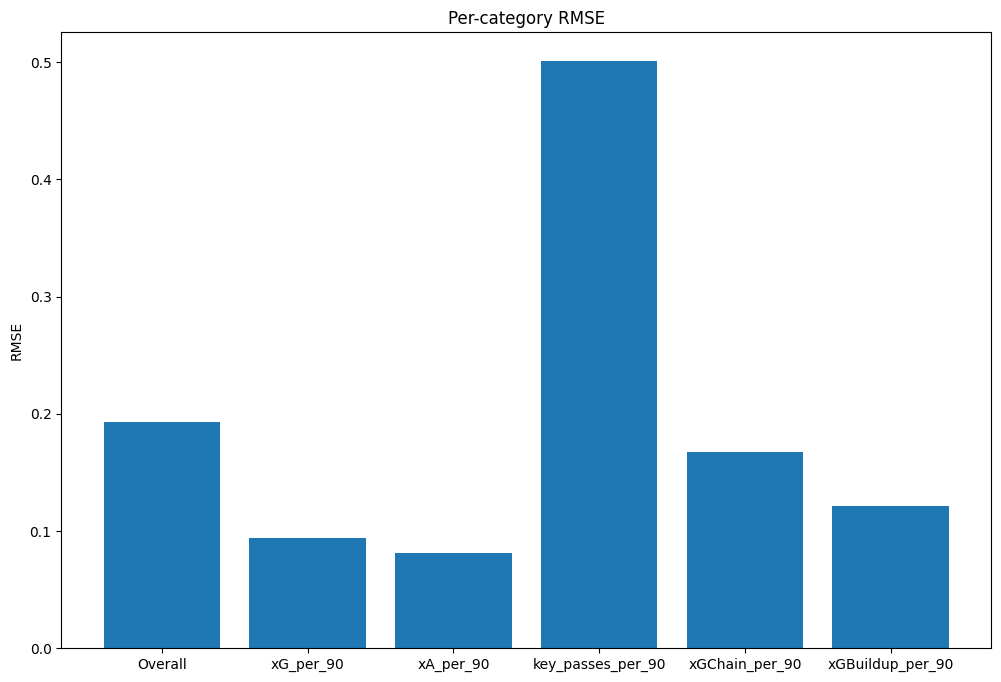

In [14]:
# Evaluate overall test performance

results_dict = model.eval_model(test_dataloader)

# Make bar chart of
cats = ["Overall"]
vals = [results_dict['Overall'][0]]

print(f"Overall test RMSE: {results_dict['Overall'][0]}")
print(f"Overall test MAE: {results_dict['Overall'][1]}")

for i, stat in enumerate(test_df.columns):
    print(f"{stat} test RMSE: {results_dict[i][0]}")
    print(f"{stat} test MAE: {results_dict[i][1]}")
    
    cats.append(stat)
    vals.append(results_dict[i][0])

plt.figure(figsize=(12, 8))
plt.bar(cats,vals)
plt.ylabel("RMSE")
plt.title("Per-category RMSE")

In [ ]:
# Look at degredation the further ahead
errors = model.look_ahead_errors(test_dataloader)

RMSE: 0.1669928878545761
MAE: 0.12916822731494904
xG_per_90 RMSE: 0.07440810650587082
xG_per_90 MAE: 0.049228910356760025
xA_per_90 RMSE: 0.08040710538625717
xA_per_90 MAE: 0.04762515798211098
key_passes_per_90 RMSE: 0.45323890447616577
key_passes_per_90 MAE: 0.35478630661964417
xGChain_per_90 RMSE: 0.12815603613853455
xGChain_per_90 MAE: 0.10984723269939423
xGBuildup_per_90 RMSE: 0.09875423461198807
xGBuildup_per_90 MAE: 0.08435343950986862


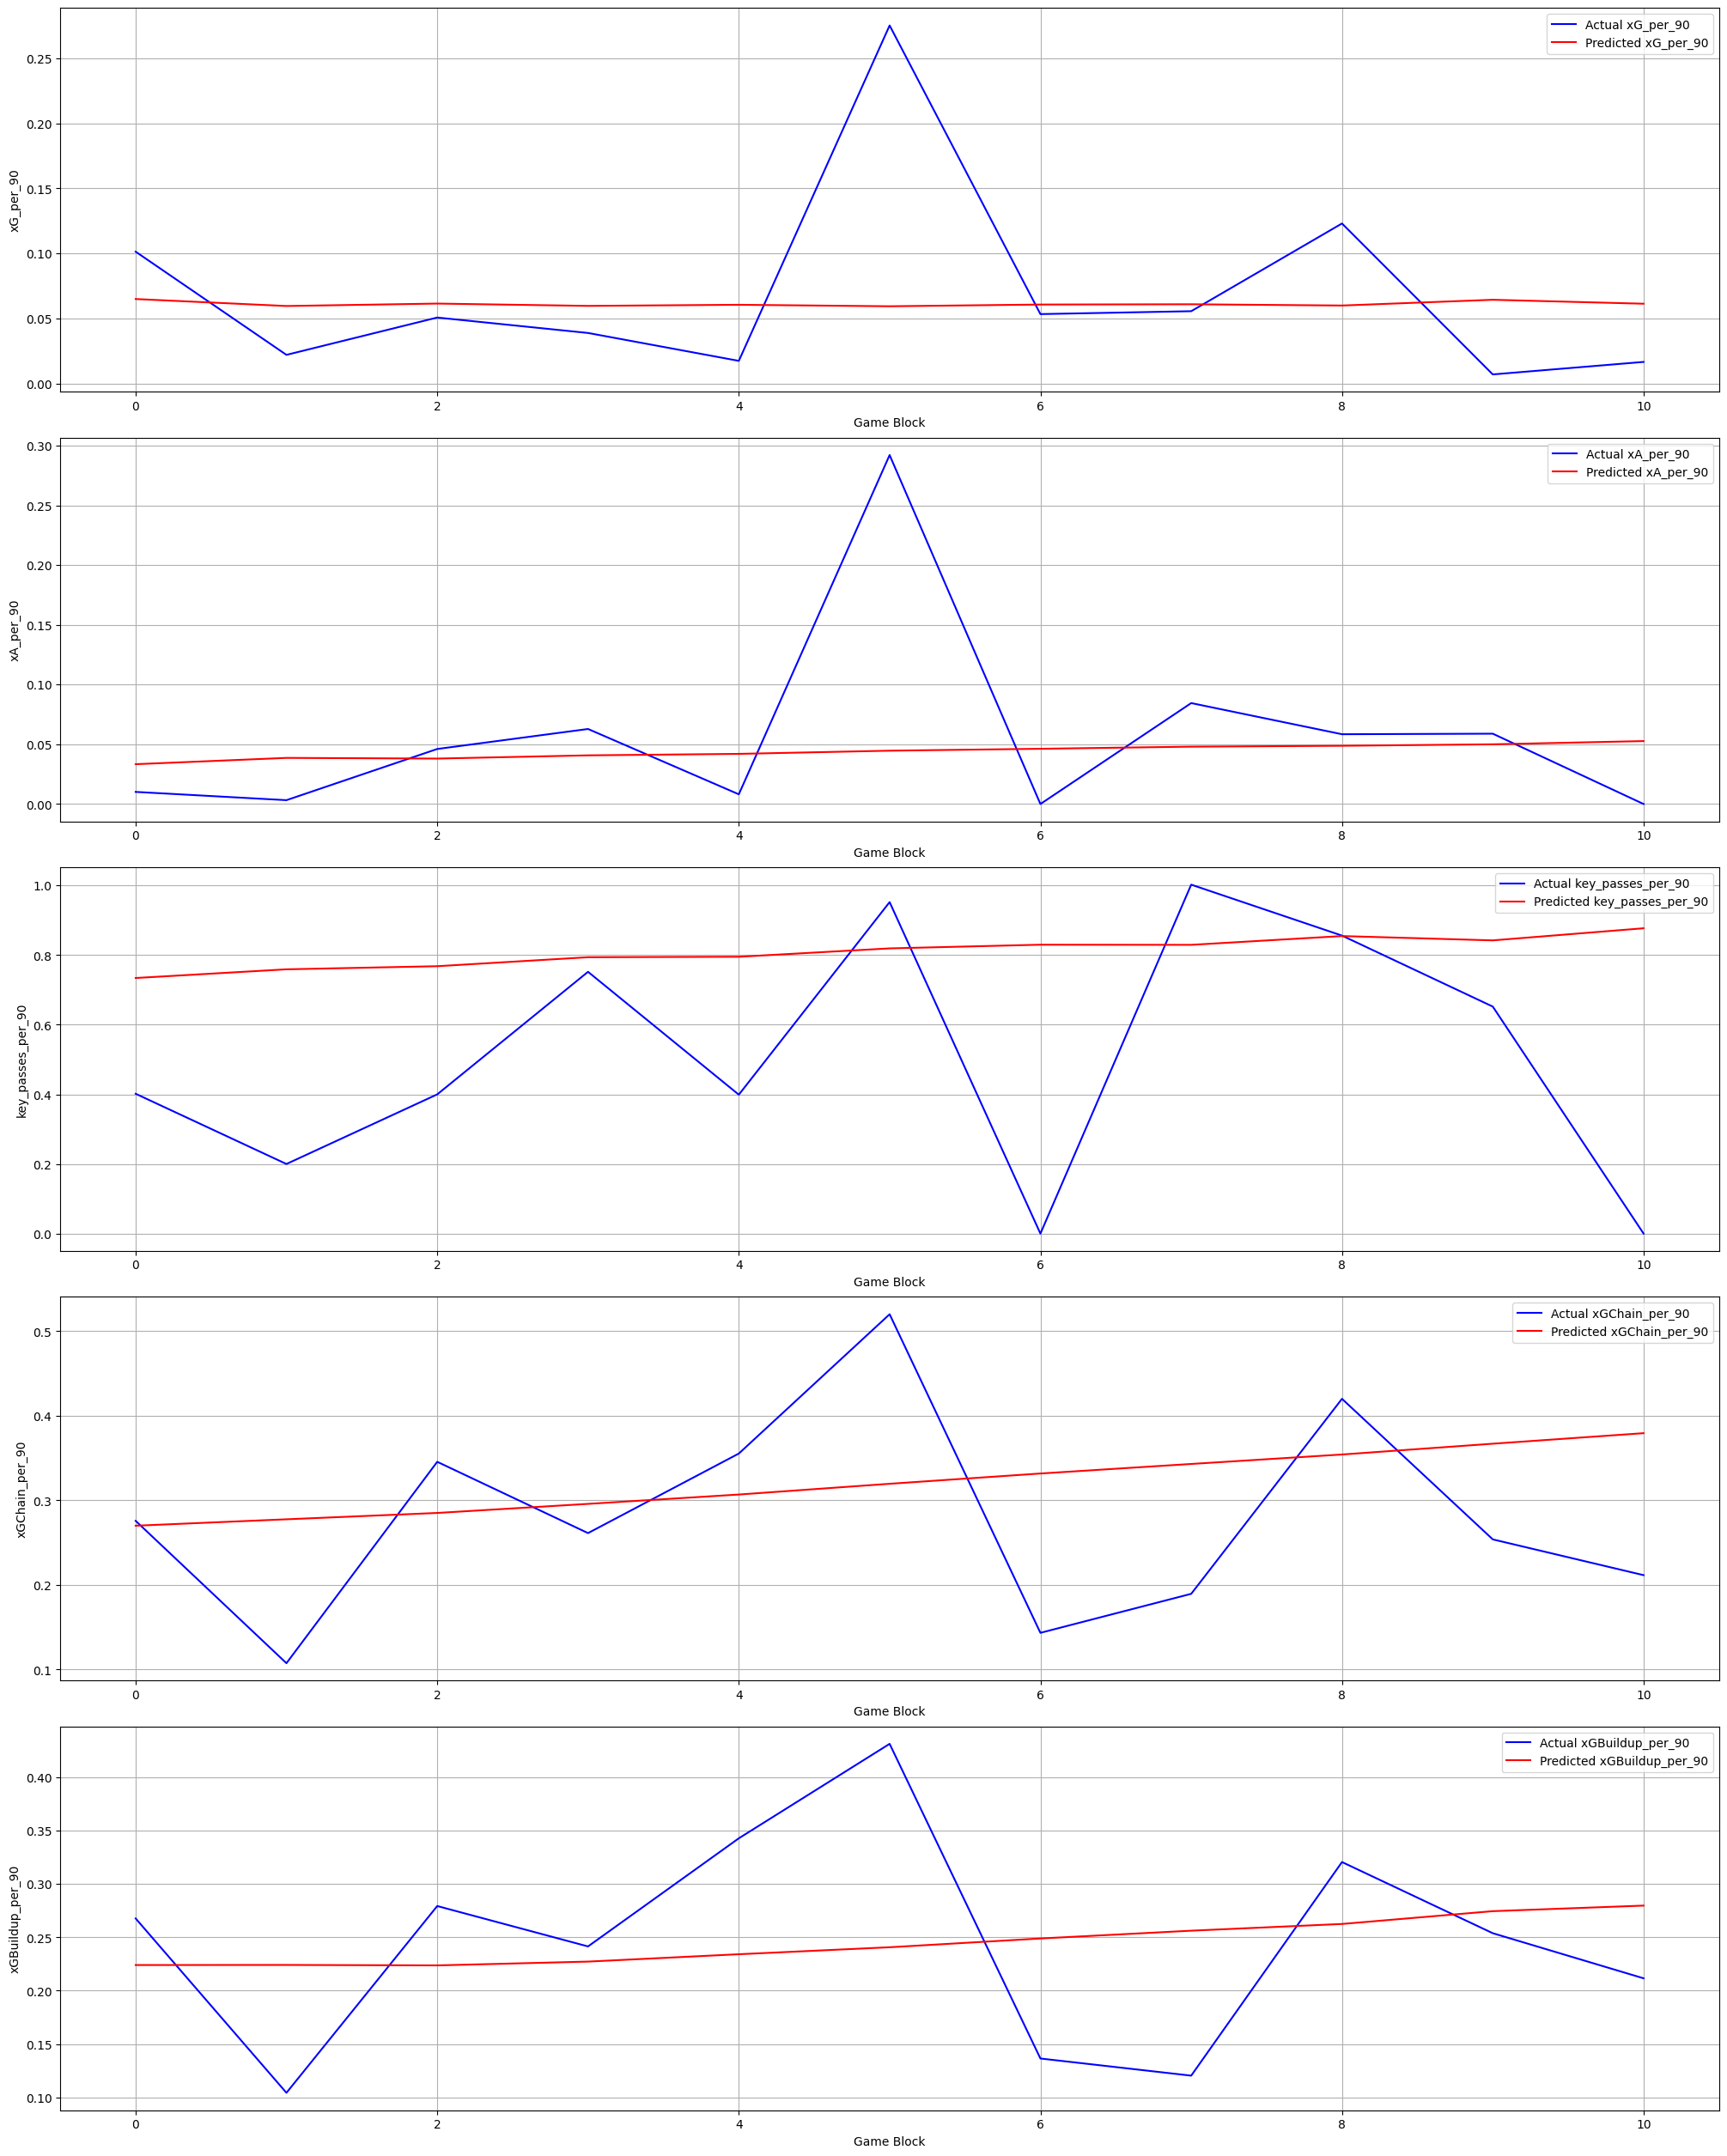

In [ ]:
# See how model does on forecasting a specific player

player_df = stats_df.loc[150]

model.eval_model_on_player(player_df)

In [ ]:
# Pull predictions for test_df and save to csv
preds_df_combined = get_actuals_vs_predictions_df(test_df, model, blocks_per_input=blocks_per_input, differencing=differencing, max_look_ahead=None)
preds_df_combined.to_csv(f"../data/{'_'.join(positions)}_differenced_set_{differencing}_predictions_real_values.csv", index=False)

      player_id        player_name                date      league  xG_per_90  \
0            26      Salomon Kalou 2016-07-02 09:15:00  Bundesliga   0.332681   
1            26      Salomon Kalou 2016-10-27 22:00:00  Bundesliga   0.326422   
2            26      Salomon Kalou 2017-02-22 10:45:00  Bundesliga   0.323567   
3            26      Salomon Kalou 2017-06-19 23:30:00  Bundesliga   0.321780   
4            26      Salomon Kalou 2017-10-15 12:15:00  Bundesliga   0.313865   
...         ...                ...                 ...         ...        ...   
3087      11965  Tijjani Reijnders 2025-10-21 13:45:00     Serie_A   0.167081   
3088      12045        Aron Dønnum 2025-06-26 05:18:45     Ligue_1   0.061361   
3089      12045        Aron Dønnum 2025-10-19 18:22:30     Ligue_1   0.064666   
3090      12149         Alex Scott 2026-03-03 02:00:00         EPL   0.041366   
3091      12294     Carlos Vicente 2025-08-02 13:22:30     La_Liga   0.136058   

      xA_per_90  key_passes